**1. Import & Load Data**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

In [2]:
PATH = "../data/raw/listings.csv"
df = pd.read_csv(PATH)

# Display all the columns
pd.set_option('display.max_columns', None)

In [3]:
df.shape

(6334, 79)

In [4]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_thumbnail_url,host_picture_url,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,132068,https://www.airbnb.com/rooms/132068,20250929230956,2025-09-30,city scrape,Great attic+terrace+parking. Beach views. ESS0...,"Amazing modern, clean & fully equiped flat of...",Gros is the trendy neighborhood of Donosti. Th...,https://a0.muscache.com/pictures/hosting/Hosti...,648938,https://www.airbnb.com/users/show/648938,Mikel,2011-05-31,"San Sebastian, Spain",Nací y crecí en San Sebastian. Al igual que vo...,within an hour,100%,100%,t,https://a0.muscache.com/im/users/648938/profil...,https://a0.muscache.com/im/users/648938/profil...,NaN,1.0,1.0,"['email', 'phone']",t,t,"Donostia-San Sebastian, Basque Country, Spain",Donostia-San SebastiÃ¡n,GuipÃºzcoa,43.324750,-1.973350,Entire condo,Entire home/apt,4,1.0,1 bath,2.0,3.0,"[""Refrigerator"", ""Microwave"", ""Essentials"", ""W...",$201.00,1,63,1.0,2.0,63.0,63.0,1.8,63.0,NaN,t,2,16,34,273,2025-09-30,818,69,6,37,67,255,51255.0,2011-06-04,2025-09-28,4.89,4.90,4.78,4.97,4.97,4.94,4.76,ESFCTU00002000700022477500000000000000000000ES...,t,1,1,0,0,4.69
1,225692,https://www.airbnb.com/rooms/225692,20250929230956,2025-09-30,city scrape,"Parte Vieja, San Sebastian",NaN,NaN,https://a0.muscache.com/pictures/31866298/de9d...,1176053,https://www.airbnb.com/users/show/1176053,Julia,2011-09-18,"San Sebastian, Spain","Hola, soy Julia, el de la foto es mi pequeño t...",within a few hours,100%,94%,t,https://a0.muscache.com/im/users/1176053/profi...,https://a0.muscache.com/im/users/1176053/profi...,NaN,1.0,1.0,"['email', 'phone']",t,t,NaN,Donostia-San SebastiÃ¡n,GuipÃºzcoa,43.324942,-1.982063,Entire rental unit,Entire home/apt,6,1.0,1 bath,3.0,4.0,"[""Pack \u2019n play/Travel crib"", ""Refrigerato...",$173.00,2,365,2.0,3.0,365.0,365.0,2.3,365.0,NaN,t,13,18,18,147,2025-09-30,293,25,0,18,30,150,25950.0,2011-10-12,2025-08-22,4.83,4.87,4.90,4.89,4.93,4.95,4.77,ESS00994,f,1,1,0,0,1.72
2,309812,https://www.airbnb.com/rooms/309812,20250929230956,2025-09-30,city scrape,Impresionante vivienda céntrica con vistas al mar,NaN,The apartment is located in the Romantic Area ...,https://a0.muscache.com/pictures/50826406/0c15...,1589633,https://www.airbnb.com/users/show/1589633,Emy,2012-01-10,"San Sebastian, Spain",My name is Emy and I am the owner of these apa...,within a few hours,100%,100%,f,https://a0.muscache.com/im/users/1589633/profi...,https://a0.muscache.com/im/users/1589633/profi...,NaN,7.0,8.0,"['email', 'phone']",t,t,"Donostia-San Sebastian, Basque Country, Spain",Donostia-San SebastiÃ¡n,GuipÃºzcoa,43.316630,-1.986160,Entire rental unit,Entire home/apt,8,2.0,2 baths,3.0,5.0,"[""Pack \u2019n play/Travel crib"", 

**2. Initial Data Cleaning & Columnb Dropping**

In [5]:
# Turn the string "price" data into numeric
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [6]:
# Drop all the rows whose price value is NaN, imputation is not an option since they're the target values
df = df.dropna(subset=["price"]).copy()

In [7]:
# Drop useless and leakage columns

cols_to_drop = [
    "id",
    "listing_url",
    "scrape_id",
    "last_scraped",
    "source",
    "picture_url",
    "host_id",
    "host_url",
    "host_thumbnail_url",
    "host_picture_url",
    "calendar_updated",          # all null
    "calendar_last_scraped",
    "estimated_revenue_l365d",   # leakage
    "estimated_occupancy_l365d", # leakage

    # text fields (no NLP)
    "name",
    "description",
    "neighborhood_overview",
    "host_about",

    # redundant/free-text versions
    "bathrooms_text",
    "host_name",          
    "host_verifications", 
]

df = df.drop(columns=cols_to_drop)

**3. Train/Test Split**

In [8]:
# Create helper bins (quantiles) for stratified train/test split on price
df["price_bin"] = pd.qcut(df["price"], q=5, duplicates="drop")

In [9]:
# Split data into 80% trainig and 20% test sets using stratification on price bins.
df_train, df_test = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["price_bin"]
)

In [10]:
# Remove the price bins from each set. 
df_train = df_train.drop(columns=["price_bin"])
df_test = df_test.drop(columns=["price_bin"])

**4. Exploratory Data Analysis**

In [11]:
df_eda = df_train.copy()

In [12]:
df_eda.shape

(4520, 58)

In [13]:
df_eda.info()

<class 'pandas.DataFrame'>
Index: 4520 entries, 1592 to 1552
Data columns (total 58 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   host_since                                    4518 non-null   str    
 1   host_location                                 3241 non-null   str    
 2   host_response_time                            4170 non-null   str    
 3   host_response_rate                            4170 non-null   str    
 4   host_acceptance_rate                          4302 non-null   str    
 5   host_is_superhost                             4389 non-null   str    
 6   host_neighbourhood                            228 non-null    str    
 7   host_listings_count                           4518 non-null   float64
 8   host_total_listings_count                     4518 non-null   float64
 9   host_has_profile_pic                          4518 non-null   str    
 10  h

In [14]:
df_eda.head()

,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
1592,2019-06-08,"Bilbao, Spain",within an hour,100%,100%,t,NaN,1.0,1.0,t,t,"Bilbao, Vizkaia, Spain, Spain",Bilbao,Vizcaya,43.256507,-2.928715,Entire rental unit,Entire home/apt,4,1.0,2.0,3.0,"[""Pack \u2019n play/Travel crib"", ""Refrigerato...",123.0,1,1125,1.0,3.0,1125.0,1125.0,1.3,1125.0,t,7,29,59,149,359,71,5,62,73,2019-06-15,2025-09-24,4.91,4.95,4.98,4.97,4.99,4.60,4.80,ESFCTU00004802700084705300000000000000000000EB...,f,1,1,0,0,4.68
1382,2017-06-04,"San Sebastián, Spain",within a few hours,90%,96%,f,NaN,10.0,10.0,t,t,"Donostia-San Sebastian, Euskadi, Spain",Donostia-San SebastiÃ¡n,GuipÃºzcoa,43.324610,-1.984080,Entire rental unit,Entire home/apt,4,1.0,3.0,4.0,"[""Refrigerator"", ""Microwave"", ""Hot water kettl...",115.0,30,300,30.0,30.0,300.0,300.0,30.0,300.0,t,25,50,76,287,5,2,0,79,1,2019-06-30,2025-07-31,5.00,5.00,5.00,5.00,5.00,4.80,4.60,ESFCNT0000200080002542430000000000000000000000...,f,10,10,0,0,0.07
2536,2012-05-26,"San Sebastián, Spain",within an hour,100%,97%,t,NaN,27.0,33.0,t,t,"Donostia-San Sebastian, Euskadi, Spain",Donostia-San SebastiÃ¡n,GuipÃºzcoa,43.323890,-1.982550,Entire rental unit,Entire home/apt,6,2.0,3.0,5.0,"[""Pack \u2019n play/Travel crib"", ""Refrigerato...",422.0,1,1125,1.0,4.0,1125.0,1125.0,3.0,1125.0,t,10,28,51,259,37,10,3,54,4,2021-07-31,2025-09-28,4.95,4.95,4.86,4.97,4.97,4.97,4.84,ESFCTU00002000800051403300000000000000000000ES...,t,25,25,0,0,0.73
986,2018-03-17,"Donostia-San Sebastian, Spain",within an hour,97%,100%,t,NaN,3.0,3.0,t,t,"Donostia-San Sebastian, Euskadi, Spain",Donostia-San SebastiÃ¡n,GuipÃºzcoa,43.314530,-1.981370,Entire rental unit,Entire home/apt,2,1.0,1.0,2.0,"[""Pack \u2019n play/Travel crib"", ""Children\u2...",129.0,2,30,1.0,2.0,1125.0,1125.0,2.0,1125.0,t,1,17,38,287,513,81,9,39,69,2018-03-25,2025-09-27,4.91,4.86,4.95,4.94,4.98,4.94,4.80,ESFCTU00002000800023810600000000000000000000ES...,t,3,3,0,0,5.60
4449,2021-08-13,NaN,within an hour,99%,99%,f,Nové Město,967.0,1058.0,t,t,"Gasteiz, Euskadi, Spain",Vitoria-Gasteiz,Ãlava,42.851525,-2.673562,Entire rental unit,Entire home/apt,6,1.0,1.0,3.0,"[""Refrigerator"", ""Microwave"", ""Shower gel"", ""E...",292.0,1,365,1.0,1.0,999.0,999.0,1.0,999.0,t,9,24,37,228,8,3,0,37,7,2024-02-28,2025-01-06,4.75,4.63,4.63,4.63,4.38,4.88,4.63,Exempt,t,18,18,0,0,0.41


In [15]:
# Check missing values per column in percentage with a descending order
missing_percentage = df_eda.isna().mean().mul(100).sort_values(ascending=False)
missing_percentage[missing_percentage > 0]

host_neighbourhood             94.955752
neighbourhood                  53.362832
host_location                  28.296460
license                        18.539823
reviews_per_month               9.336283
review_scores_value             9.336283
review_scores_communication     9.336283
review_scores_checkin           9.336283
review_scores_accuracy          9.336283
last_review                     9.336283
review_scores_cleanliness       9.336283
review_scores_location          9.336283
review_scores_rating            9.336283
first_review                    9.336283
host_response_time              7.743363
host_response_rate              7.743363
host_acceptance_rate            4.823009
host_is_superhost               2.898230
has_availability                0.575221
beds                            0.243363
bathrooms                       0.088496
host_identity_verified          0.044248
host_has_profile_pic            0.044248
host_total_listings_count       0.044248
host_listings_co

In [16]:
df_eda.describe()

,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,availability_30,availability_60,availability_90,availability_365,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,4518.000000,4518.000000,4520.000000,4520.000000,4520.000000,4516.000000,4518.000000,4509.000000,4520.000000,4520.000000,4.520000e+03,4518.000000,4518.000000,4518.000000,4518.000000,4520.000000,4520.000000,4520.000000,4520.000000,4520.000000,4520.000000,4520.000000,4520.000000,4520.000000,4520.000000,4520.000000,4098.000000,4098.000000,4098.000000,4098.000000,4098.000000,4098.000000,4098.000000,4520.000000,4520.000000,4520.000000,4520.000000,4098.000000
mean,21.817176,30.585215,43.260544,-2.510491,4.043805,1.518379,1.992917,3.017964,209.796239,3.103540,2.290641e+04,2.935370,5.195440,563.974325,696.251439,3.959137,650.910487,15.152434,36.098894,58.142920,203.566593,60.858628,13.651770,1.255531,59.928761,12.061504,4.749219,4.793960,4.774156,4.782118,4.833536,4.744287,4.609646,11.655088,10.059956,1.374115,0.126327,1.549048
std,84.068742,133.489193,0.151415,0.435468,2.342981,1.019356,1.271072,2.362151,602.983507,7.113805,1.487473e+06,6.560006,9.134064,469.972028,659.008251,7.305327,626.160001,9.812605,18.250408,26.825556,119.513660,97.012375,21.215185,1.997224,27.678836,17.938185,0.322975,0.301659,0.308285,0.301964,0.273252,0.330174,0.380726,26.532462,26.558985,3.303032,1.614061,1.829270
min,1.000000,1.000000,42.487640,-3.378762,1.000000,0.000000,0.000000,0.000000,16.000000,1.000000,1.000000e+00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.010000
25%,1.000000,1.000000,43.257148,-2.925680,2.000000,1.000000,1.000000,1.000000,88.000000,1.000000,1.800000e+02,1.000000,2.000000,35.000000,365.000000,1.400000,329.700000,7.000000,25.000000,45.000000,86.000000,6.000000,1.000000,0.000000,46.000000,0.000000,4.670000,4.740000,4.700000,4.710000,4.780000,4.660000,4.500000,1.000000,1.000000,0.000000,0.000000,0.440000
50%,3.000000,3.000000,43.299497,-2.670280,4.000000,1.000000,2.000000,3.000000,129.000000,2.000000,3.650000e+02,2.000000,3.000000,365.000000,730.000000,2.000000,365.000000,15.000000,39.000000,65.000000,219.500000,25.000000,7.000000,0.000000,67.000000,5.000000,4.830000,4.870000,4.860000,4.870000,4.920000,4.830000,4.690000,2.000000,1.000000,0.000000,0.000000,1.000000
75%,10.000000,12.000000,43.323660,-1.985796,5.000000,2.000000,3.000000,4.000000,199.000000,2.000000,1.125000e+03,2.000000,5.000000,1125.000000,1125.000000,3.000000,1125.000000,24.000000,51.000000,79.000000,322.000000,71.000000,19.000000,2.000000,82.000000,16.000000,4.940000,4.960000,4.960000,4.950000,4.990000,4.950000,4.830000,8.000000,4.000000,1.000000,0.000000,2.110000
max,967.000000,5020.000000,43.441490,-1.757010,16.000000,24.000000,25.000000,48.000000,14362.000000,160.000000,1.000000e+08,100.000000,140.000000,1500.000000,9999.000000,100.000000,9917.100000,30.000000,60.000000,90.000000,365.000000,1278.000000,702.000000,32.000000,93.000000,163.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,149.000000,149.000000,32.000000,25.000000,47.610000


The price data is right-skewed, there are outliers which can distort the model, so we may try to apply log transformation on prices to make the distribution more balanced. 

<Axes: >

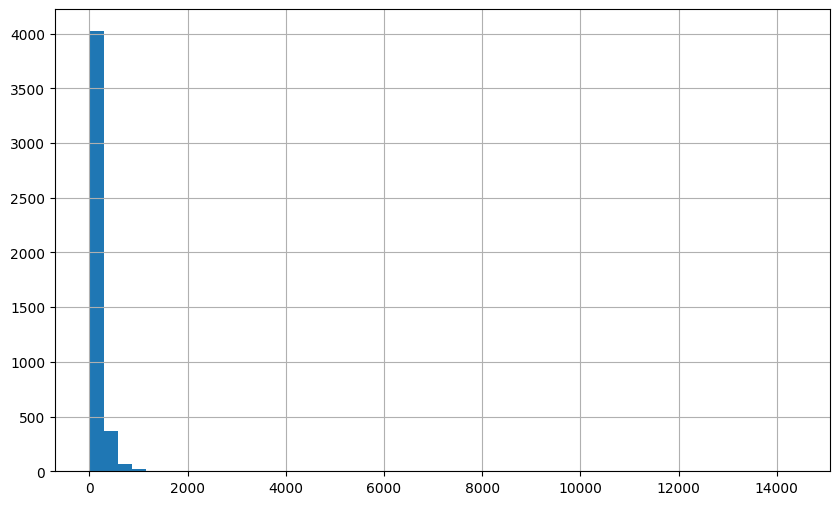

In [17]:
# Check the distribution of the target variable with a histogram. 
df_eda["price"].hist(bins=50, figsize=(10, 6))

<Axes: >

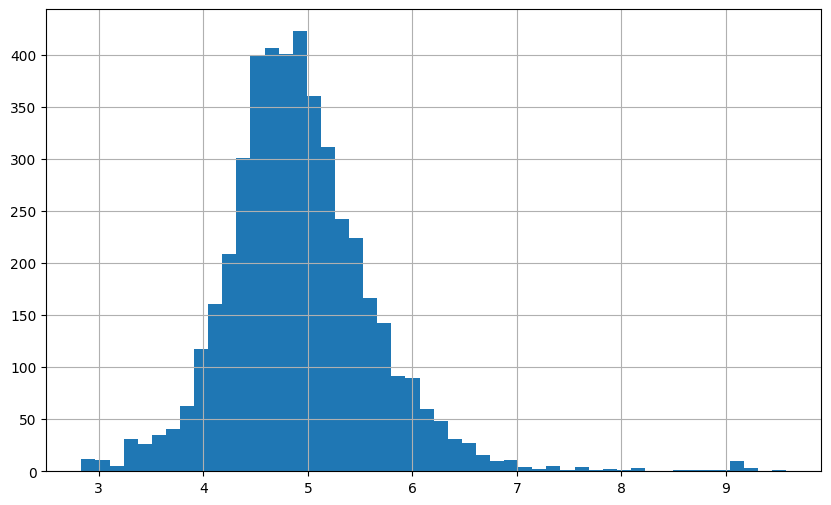

In [18]:
# Check the target variable with a histogram after log transformation. It's more normal now.
np.log1p(df_eda["price"]).hist(bins=50, figsize=(10, 6))

As we can see, the large values are compressed, skewness reduced and the price data is more normal now.

**4.a. Analysis of Numerical Features**

In [19]:
numeric_cols = df_eda.select_dtypes(include="number").columns
features = numeric_cols.drop("price") # Drop the target from the feature list

In [20]:
# Create a correlation matrix of the numeric features with the log-transformed target variable and sort it in descending order.
corr = df_eda[features].corrwith(np.log1p(df_eda["price"])).sort_values(ascending=False)
corr

accommodates                                    0.522479
bedrooms                                        0.453369
beds                                            0.417159
bathrooms                                       0.370313
host_listings_count                             0.289521
host_total_listings_count                       0.279232
review_scores_location                          0.199290
longitude                                       0.194356
calculated_host_listings_count_entire_homes     0.191127
calculated_host_listings_count                  0.167939
review_scores_rating                            0.126988
availability_365                                0.118792
review_scores_cleanliness                       0.112547
review_scores_accuracy                          0.080872
availability_eoy                                0.078641
availability_90                                 0.078567
availability_30                                 0.074839
review_scores_checkin          

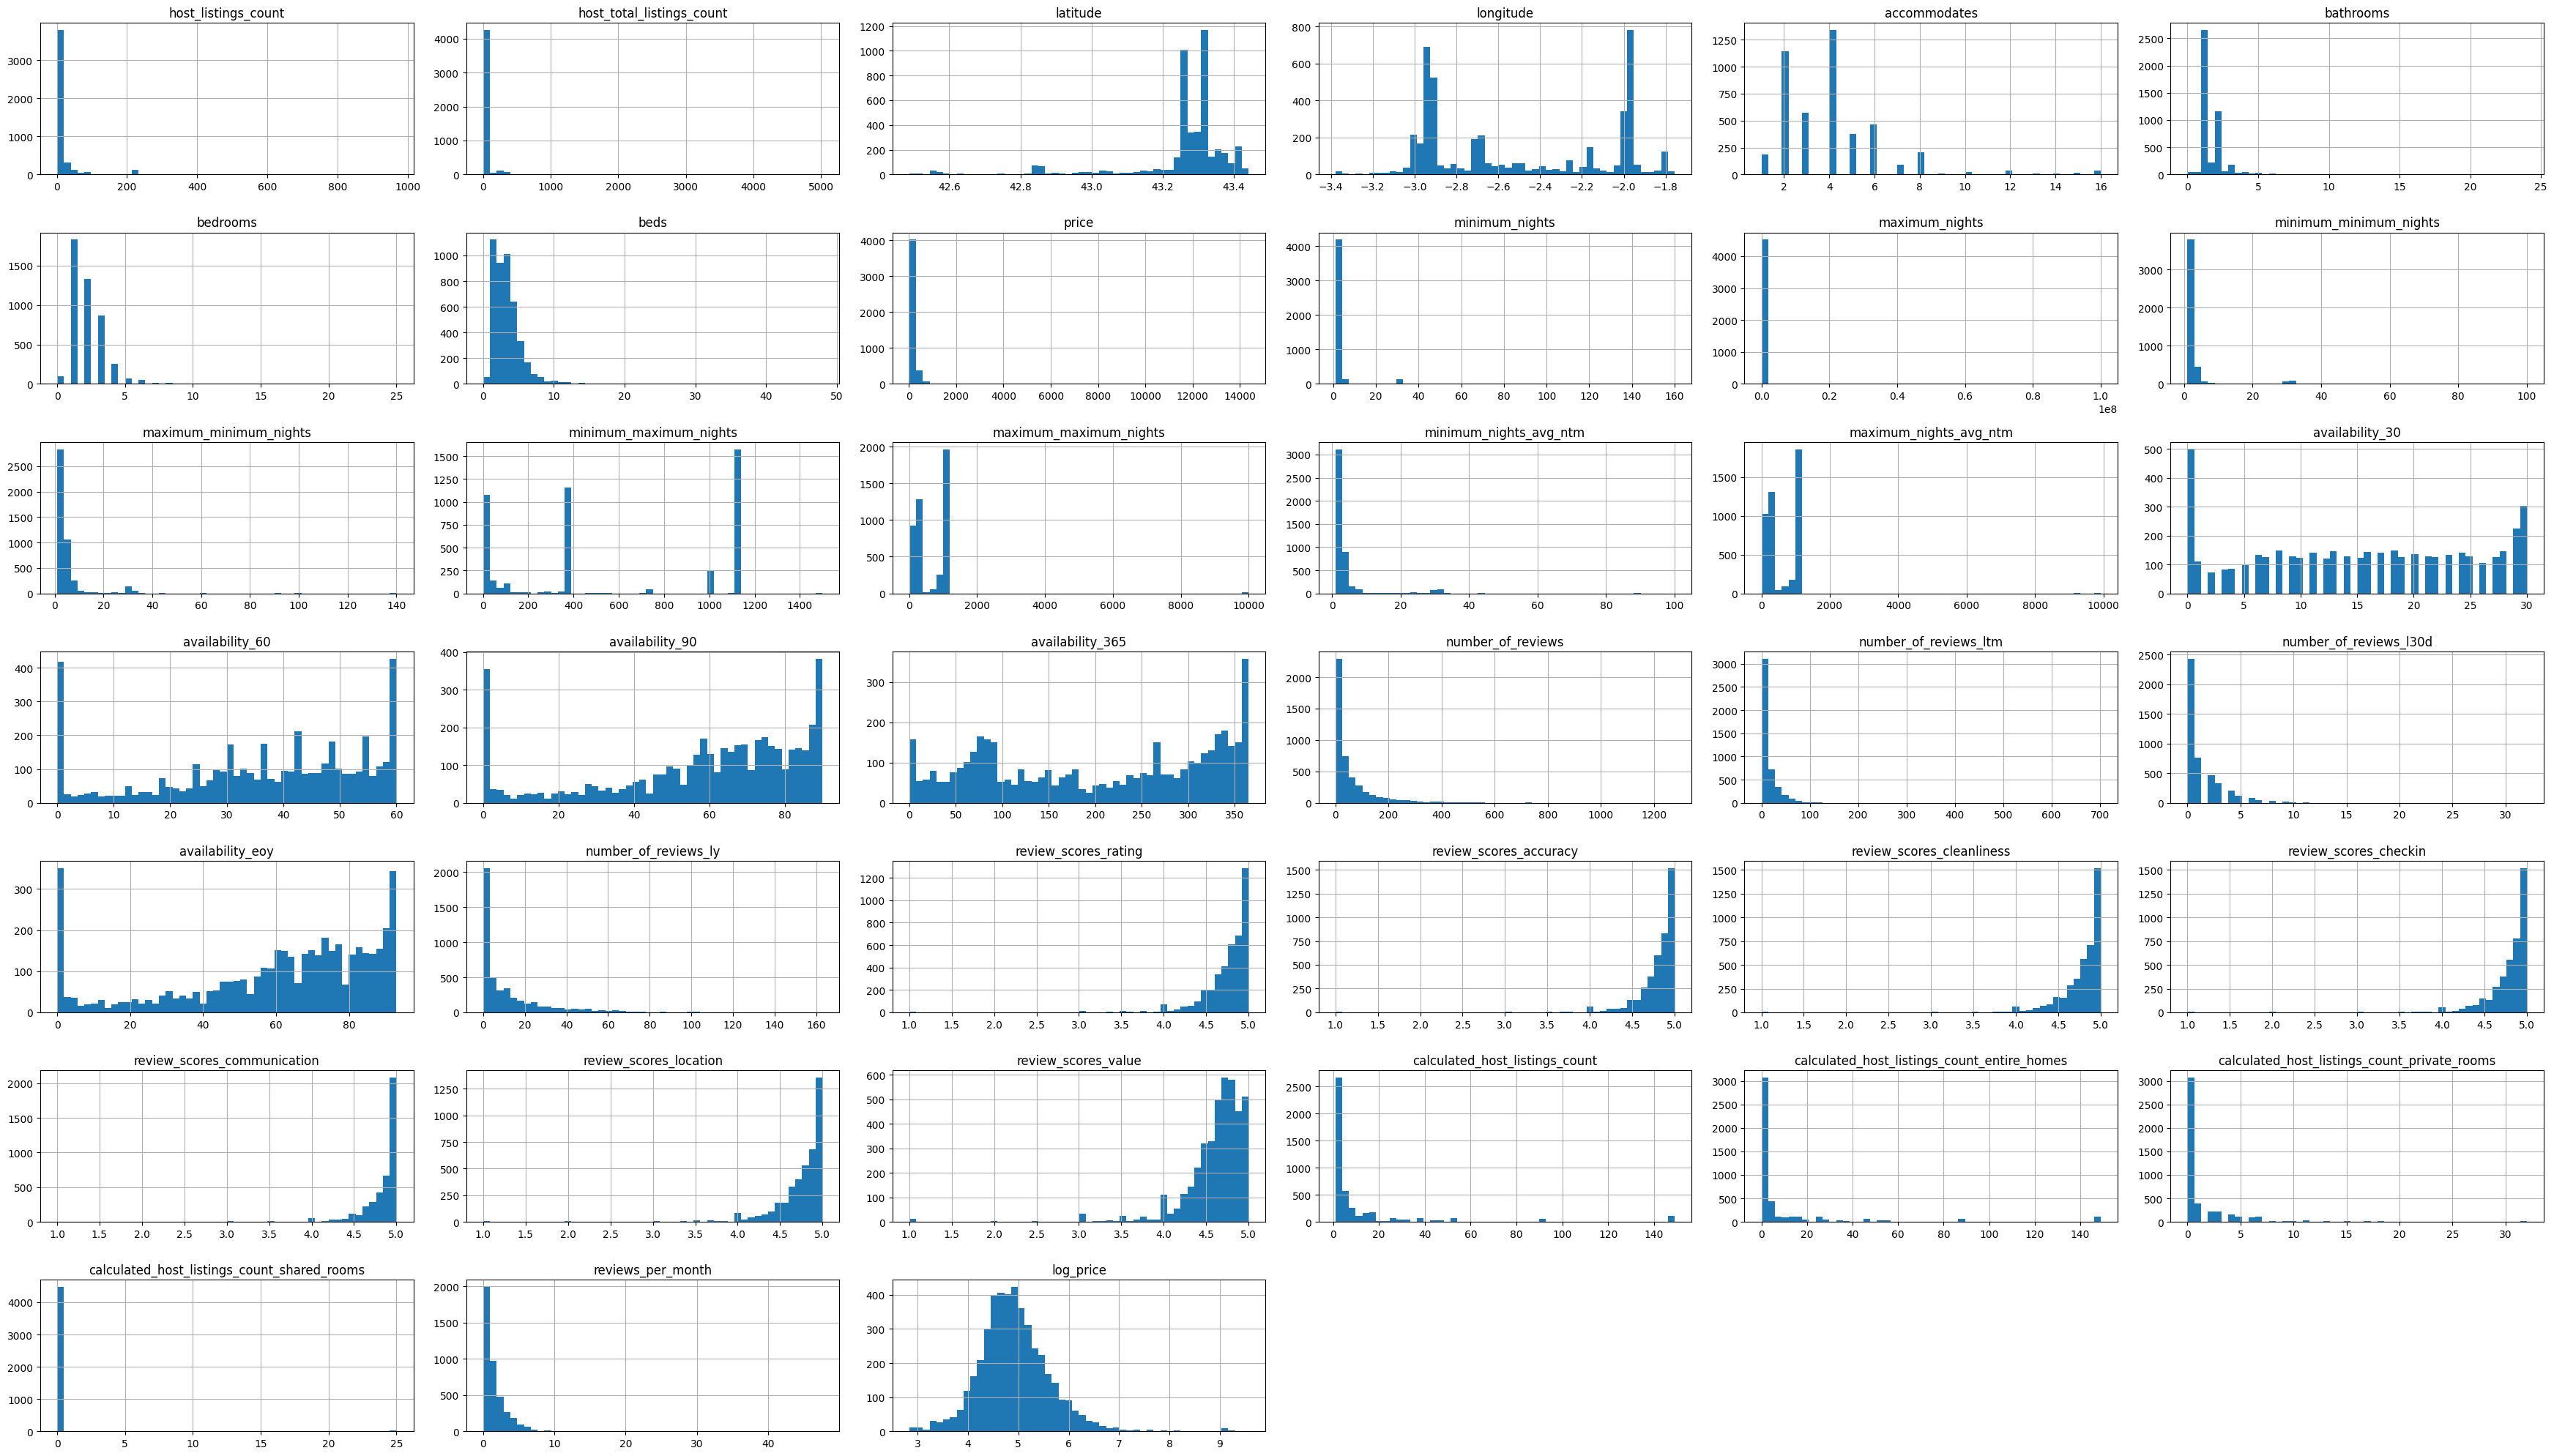

In [21]:
df_eda["log_price"] = np.log1p(df_eda["price"])

# Plot the histograms for all numeric columns in df_eda to 
# check their distributions. We can apply transformations later if needed.
df_eda.select_dtypes(include="number").hist(
    bins=50, 
    figsize=(35, 20), 
    grid=True
)
plt.tight_layout()
plt.show()

df_eda = df_eda.drop(columns=["price"])

array([[<Axes: xlabel='accommodates', ylabel='accommodates'>,
        <Axes: xlabel='bedrooms', ylabel='accommodates'>,
        <Axes: xlabel='beds', ylabel='accommodates'>,
        <Axes: xlabel='bathrooms', ylabel='accommodates'>,
        <Axes: xlabel='review_scores_location', ylabel='accommodates'>,
        <Axes: xlabel='log_price', ylabel='accommodates'>],
       [<Axes: xlabel='accommodates', ylabel='bedrooms'>,
        <Axes: xlabel='bedrooms', ylabel='bedrooms'>,
        <Axes: xlabel='beds', ylabel='bedrooms'>,
        <Axes: xlabel='bathrooms', ylabel='bedrooms'>,
        <Axes: xlabel='review_scores_location', ylabel='bedrooms'>,
        <Axes: xlabel='log_price', ylabel='bedrooms'>],
       [<Axes: xlabel='accommodates', ylabel='beds'>,
        <Axes: xlabel='bedrooms', ylabel='beds'>,
        <Axes: xlabel='beds', ylabel='beds'>,
        <Axes: xlabel='bathrooms', ylabel='beds'>,
        <Axes: xlabel='review_scores_location', ylabel='beds'>,
        <Axes: xlabel='log_pr

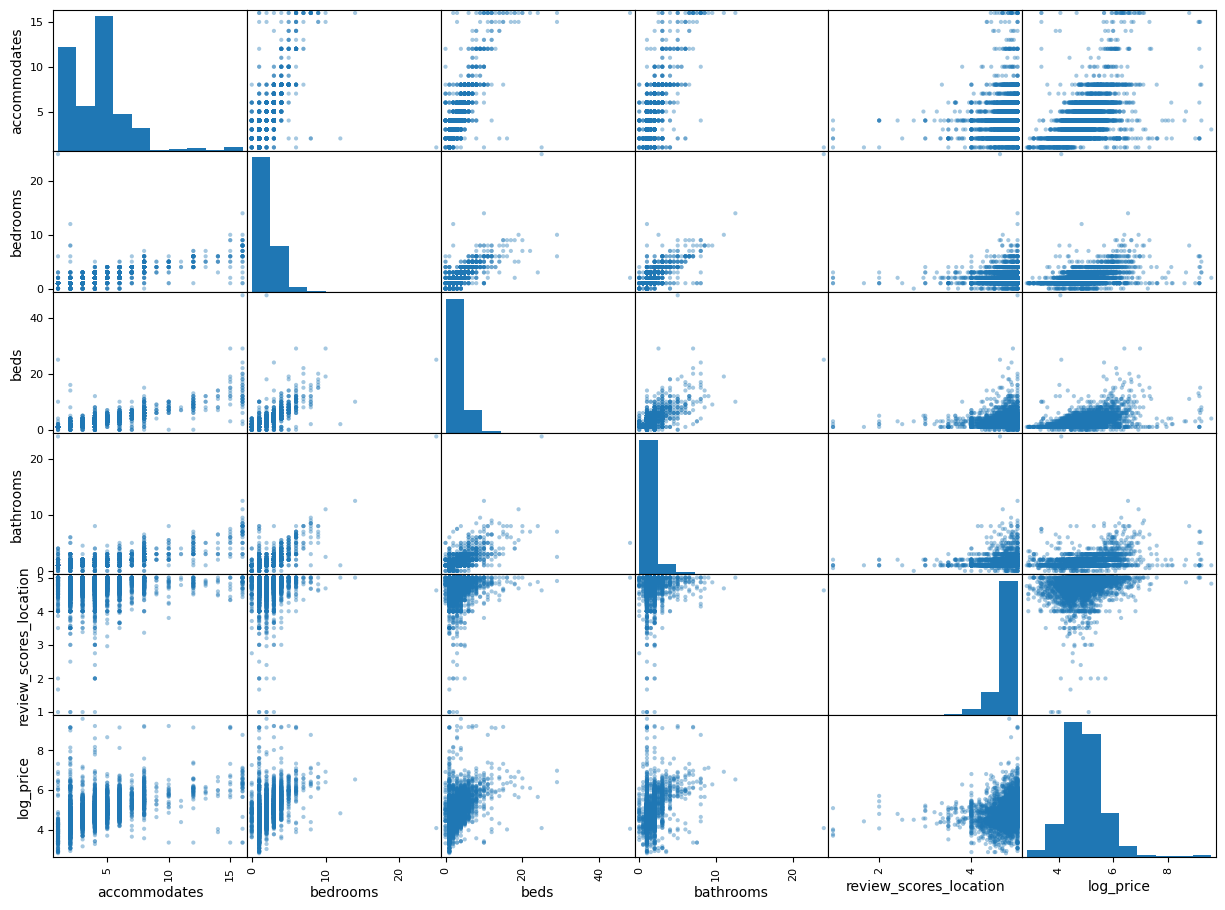

In [22]:
from pandas.plotting import scatter_matrix

attributes = [
    "accommodates",
    "bedrooms",
    "beds",
    "bathrooms",
    "review_scores_location",
    "log_price" 
]

scatter_matrix(
    df_eda[attributes],
    figsize=(15, 11),
    alpha=0.4
)

* **Checking the log transformation candidates**

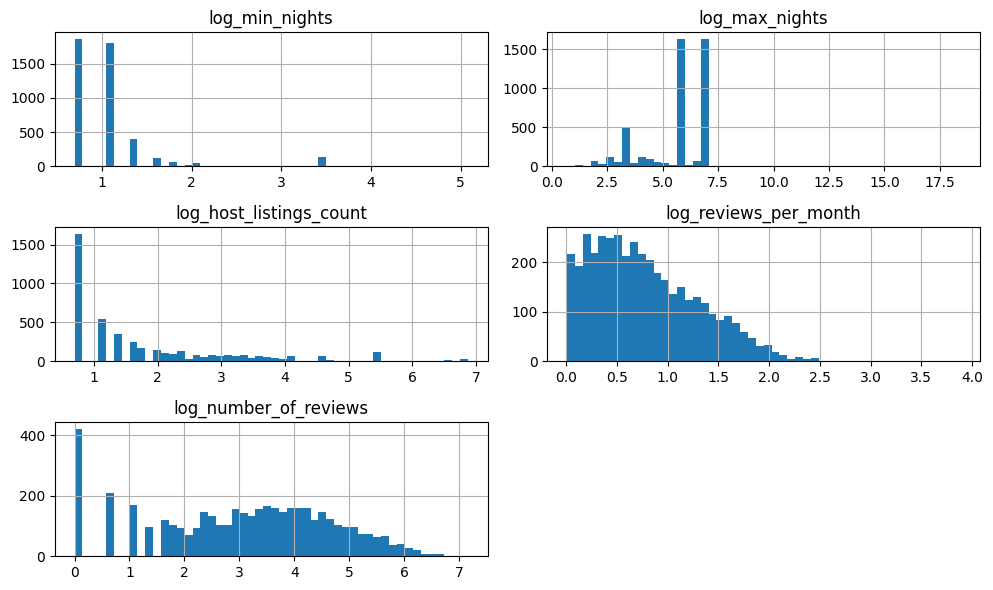

In [23]:
log_candidates = pd.DataFrame({
    "log_min_nights": np.log1p(df_eda["minimum_nights"]),
    "log_max_nights": np.log1p(df_eda["maximum_nights"]),
    "log_host_listings_count": np.log1p(df_eda["host_listings_count"]),
    "log_reviews_per_month": np.log1p(df_eda["reviews_per_month"]),
    "log_number_of_reviews": np.log1p(df_eda["number_of_reviews"]),
})

log_candidates.hist(bins=50, figsize=(10, 6))
plt.tight_layout()
plt.show()

**Log Transform Candidates**

* host_listings_count
* reviews_per_month
* number_of_reviews

In [24]:
log_candidates.corrwith(df_eda["log_price"]).sort_values(ascending=False)

log_host_listings_count    0.190696
log_max_nights             0.010792
log_min_nights            -0.025455
log_number_of_reviews     -0.102999
log_reviews_per_month     -0.158791
dtype: float64

In [25]:
log_candidates.describe()

,log_min_nights,log_max_nights,log_host_listings_count,log_reviews_per_month,log_number_of_reviews
count,4520.000000,4520.000000,4518.000000,4098.000000,4520.000000
mean,1.091558,5.692606,1.769494,0.780645,3.051721
std,0.577528,1.478338,1.290078,0.523842,1.651113
min,0.693147,0.693147,0.693147,0.009950,0.000000
25%,0.693147,5.198497,0.693147,0.364643,1.945910
50%,1.098612,5.902633,1.386294,0.693147,3.258097
75%,1.098612,7.026427,2.397895,1.134623,4.276666
max,5.081404,18.420681,6.875232,3.883829,7.153834


* **Checking the "clip" (or log+clip) candidates**

In [26]:
clip_candidates = pd.DataFrame({ 
    "beds_clipped": df_eda["beds"].clip(upper=10),
    "log_minimum_nights_clipped": np.log1p(df_eda["minimum_nights"].clip(upper=3)),
    "log_maximum_nights_clipped": np.log1p(df_eda["maximum_nights"].clip(upper=7.5)),
})

In [27]:
clip_candidates.corrwith(df_eda["log_price"]).sort_values(ascending=False)

beds_clipped                  0.457940
log_minimum_nights_clipped    0.024243
log_maximum_nights_clipped   -0.114349
dtype: float64

All of the three get improved after clipping, so we'll keep these.

* **Analysis of Geographical Features**

<Axes: xlabel='longitude', ylabel='latitude'>

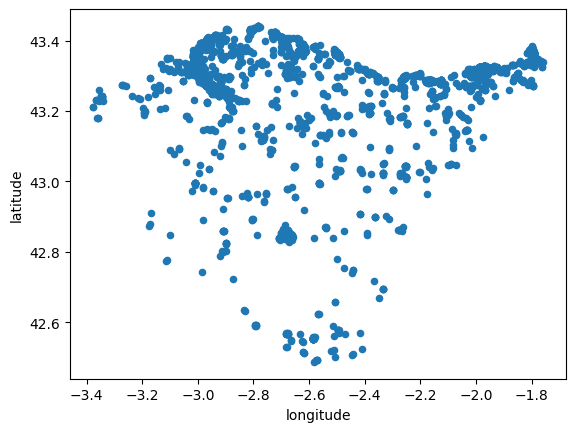

In [28]:
df_eda.plot(kind="scatter", x="longitude", y="latitude")

<Axes: xlabel='longitude', ylabel='latitude'>

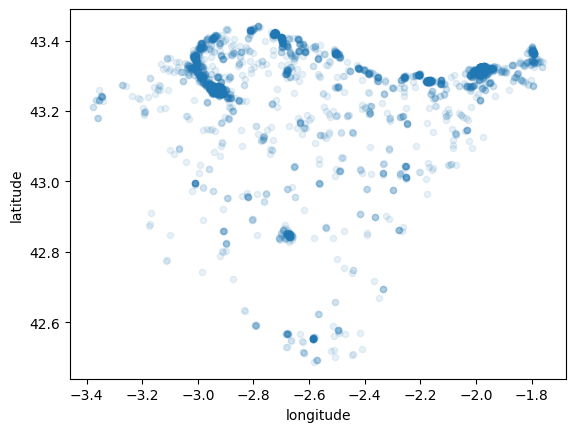

In [29]:
df_eda.plot(kind="scatter", x="longitude", y="latitude", alpha=0.1)

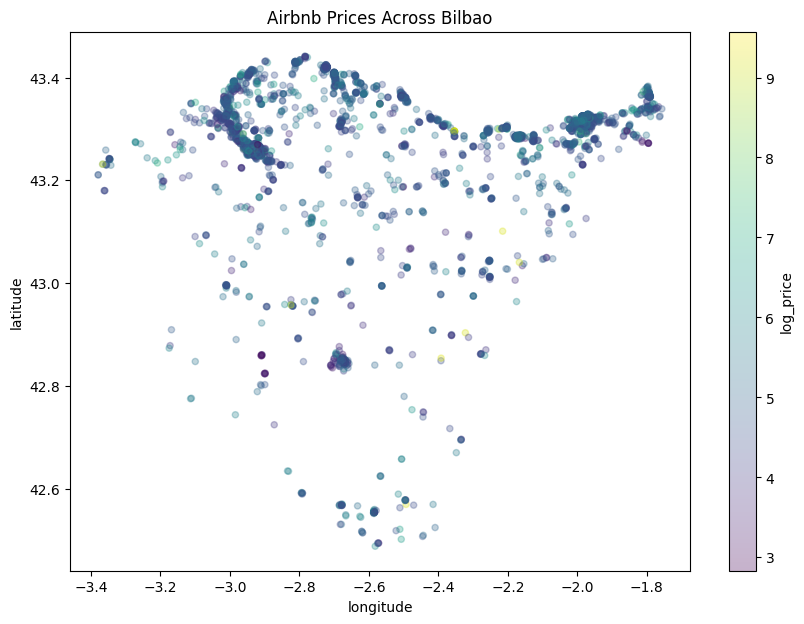

In [30]:
df_eda.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.3,
    c="log_price", 
    cmap="viridis",
    colorbar=True,
    figsize=(10,7)
)

plt.title("Airbnb Prices Across Bilbao")
plt.show()

In [31]:
# 1. Define your center point (Bilbao - Plaza Moyúa)
BILBAO_CENTER_LAT = 43.2630
BILBAO_CENTER_LON = -2.9350

# 2. Calculate the basic Euclidean distance
df_eda["distance_to_center"] = np.sqrt(
    (df_eda["latitude"] - BILBAO_CENTER_LAT)**2 + 
    (df_eda["longitude"] - BILBAO_CENTER_LON)**2
)

df_eda[["distance_to_center", "longitude", "latitude"]].corrwith(df_eda["log_price"])

distance_to_center    0.191787
longitude             0.194356
latitude              0.061488
dtype: float64

Although *distance_to_center* showed a relatively low individual correlation with price, we are keeping all three geographic features because we plan to test **Ridge Regression**.

**4.b. Analysis of Categorical Features**

In [32]:
# Get a list of all categorical columns
categorical_cols = df_eda.select_dtypes(include=["object", "string"]).columns

print(len(categorical_cols))
categorical_cols

20


Index(['host_since', 'host_location', 'host_response_time',
       'host_response_rate', 'host_acceptance_rate', 'host_is_superhost',
       'host_neighbourhood', 'host_has_profile_pic', 'host_identity_verified',
       'neighbourhood', 'neighbourhood_cleansed',
       'neighbourhood_group_cleansed', 'property_type', 'room_type',
       'amenities', 'has_availability', 'first_review', 'last_review',
       'license', 'instant_bookable'],
      dtype='str')

In [33]:
df_eda[categorical_cols].head()

,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,property_type,room_type,amenities,has_availability,first_review,last_review,license,instant_bookable
1592,2019-06-08,"Bilbao, Spain",within an hour,100%,100%,t,NaN,t,t,"Bilbao, Vizkaia, Spain, Spain",Bilbao,Vizcaya,Entire rental unit,Entire home/apt,"[""Pack \u2019n play/Travel crib"", ""Refrigerato...",t,2019-06-15,2025-09-24,ESFCTU00004802700084705300000000000000000000EB...,f
1382,2017-06-04,"San Sebastián, Spain",within a few hours,90%,96%,f,NaN,t,t,"Donostia-San Sebastian, Euskadi, Spain",Donostia-San SebastiÃ¡n,GuipÃºzcoa,Entire rental unit,Entire home/apt,"[""Refrigerator"", ""Microwave"", ""Hot water kettl...",t,2019-06-30,2025-07-31,ESFCNT0000200080002542430000000000000000000000...,f
2536,2012-05-26,"San Sebastián, Spain",within an hour,100%,97%,t,NaN,t,t,"Donostia-San Sebastian, Euskadi, Spain",Donostia-San SebastiÃ¡n,GuipÃºzcoa,Entire rental unit,Entire home/apt,"[""Pack \u2019n play/Travel crib"", ""Refrigerato...",t,2021-07-31,2025-09-28,ESFCTU00002000800051403300000000000000000000ES...,t
986,2018-03-17,"Donostia-San Sebastian, Spain",within an hour,97%,100%,t,NaN,t,t,"Donostia-San Sebastian, Euskadi, Spain",Donostia-San SebastiÃ¡n,GuipÃºzcoa,Entire rental unit,Entire home/apt,"[""Pack \u2019n play/Travel crib"", ""Children\u2...",t,2018-03-25,2025-09-27,ESFCTU00002000800023810600000000000000000000ES...,t
4449,2021-08-13,NaN,within an hour,99%,99%,f,Nové Město,t,t,"Gasteiz, Euskadi, Spain",Vitoria-Gasteiz,Ãlava,Entire rental unit,Entire home/apt,"[""Refrigerator"", ""Microwave"", ""Shower gel"", ""E...",t,2024-02-28,2025-01-06,Exempt,t


In [34]:
# Convert percentage strings to floats (fake strings)
rates = ["host_response_rate", "host_acceptance_rate"]
for col in rates:
    df_eda[col] = df_eda[col].astype(str).str.replace("%", "").astype(float) / 100

In [35]:
# Convert 't'/'f' to 1/0
booleans = [
    "host_is_superhost", "host_has_profile_pic", "host_identity_verified", 
    "has_availability", "instant_bookable"
]
for col in booleans:
    df_eda[col] = df_eda[col].map({'t': 1, 'f': 0})

In [36]:
cat_cols_to_drop = [
    "host_since", "first_review", "last_review", 
    "amenities", "license", 
    "host_location", "host_neighbourhood", 
    "neighbourhood", "neighbourhood_cleansed",
]

# Drop them from your EDA dataframe
df_eda = df_eda.drop(columns=cat_cols_to_drop, errors="ignore")

In [37]:
print(f"Unique property types: {df_eda['property_type'].nunique()}")
print(f"Unique neighborhood groups: {df_eda['neighbourhood_group_cleansed'].nunique()}")

Unique property types: 61
Unique neighborhood groups: 3


In [38]:
# Calculate the percentage of total listings for each property type
prop_percentages = df_eda["property_type"].value_counts(normalize=True) * 100
print(prop_percentages.head(15).round(2).astype(str) + '%')

property_type
Entire rental unit                   57.19%
Private room in rental unit          10.44%
Entire home                           5.46%
Private room in home                  4.54%
Room in hotel                         2.04%
Private room in bed and breakfast     1.88%
Entire condo                          1.84%
Entire cottage                        1.81%
Private room in hostel                1.46%
Private room in cottage               1.26%
Entire serviced apartment             0.82%
Room in boutique hotel                0.82%
Entire villa                          0.75%
Entire loft                           0.75%
Entire townhouse                      0.64%
Name: proportion, dtype: str


In [39]:
# Define how many top categories you want to keep
TOP_K = 5 

# Find the names of those top 5 categories
top_properties = df_eda["property_type"].value_counts().nlargest(TOP_K).index

# Replace anything NOT in that top 5 list with 'Other'
df_eda["property_type_clean"] = df_eda["property_type"].where(
    df_eda["property_type"].isin(top_properties), 
    "Other"
)

# Prove it worked
print(df_eda["property_type_clean"].value_counts())

property_type_clean
Entire rental unit             2585
Other                           919
Private room in rental unit     472
Entire home                     247
Private room in home            205
Room in hotel                    92
Name: count, dtype: int64
